In [1]:
import pandas as pd
import numpy as np
import sklearn 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

In [2]:
# 1. Call the function to fetch the data object
housing = fetch_california_housing(as_frame = True) # as_frame for direct DataFrame
X = housing.data
Y = housing.target


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.20, random_state= 456 # last 3 id digits
)

In [4]:
scale = StandardScaler()

# Fit the scaler ONLY on the training data, then transform both sets
X_train_scaled = pd.DataFrame(
    scale.fit_transform(X_train), 
    columns=X_train.columns, 
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scale.transform(X_test), 
    columns=X_test.columns, 
    index=X_test.index
)

In [5]:
X_train_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
1022,-0.746693,-0.922976,1.432652,1.590760,-0.957080,-0.075436,1.435423,-0.108500
7945,0.282415,1.225602,-0.084085,-0.224180,-0.386435,-0.000879,-0.823579,0.711551
3980,0.239169,0.429832,0.048203,-0.197956,-0.929738,-0.016605,-0.673604,0.476536
10689,-0.530571,-0.763822,-0.529645,-0.280413,-0.933266,-0.154423,-0.940747,0.921564
11510,0.419298,0.191101,-0.479132,0.017933,-0.758633,-0.110601,-0.884507,0.731552


## Training an MLP Regressor

In [28]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 1. Initialize the baseline model
# hidden_layer_sizes=(64, 32) creates two hidden layers
# activation='relu' fulfills the non-linear requirement
# solver='adam' is a robust optimizer for regression
baseline_model = MLPRegressor(
    hidden_layer_sizes=(64, 32), # Typical neuron layering size, BUT will explore this deeper
    activation='relu', # As mentioned in the briefing
    solver='adam', # Best solver for dataset(>10K)
    max_iter=500, # Not too high to sav time
    random_state= 143
)

# 2. Train the model on the scaled training data
print("Training the baseline model...")
baseline_model.fit(X_train_scaled, y_train)

train_acc = baseline_model.score(X_train_scaled, y_train) #R^2 test to check if the model is underfitting or overfitting
test_acc = baseline_model.score(X_test_scaled, y_test)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

# 3. Evaluate on the test set to get our baseline performance
# We use the test set here just to see how the baseline performs [cite: 62, 64]
y_pred_baseline = baseline_model.predict(X_test_scaled)
baseline_mse = mean_squared_error(y_test, y_pred_baseline)

print(f"Baseline Test Mean Squared Error: {baseline_mse:.4f}")

Training the baseline model...
Train accuracy: 0.8329258067405092
Test accuracy: 0.8124074956800539
Baseline Test Mean Squared Error: 0.2569


The test accuracy and train accuracy being so similar shows that the model is neither overfitting nor underfitting

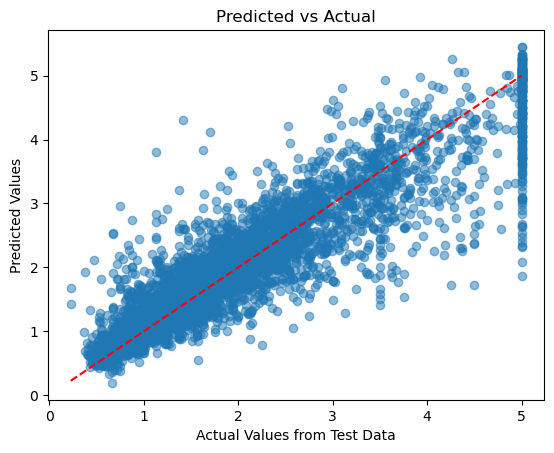

In [26]:
plt.scatter(y_test, y_pred_baseline, alpha =0.5)
plt.xlabel("Actual Values from Test Data")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.show()